In [20]:
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("./MLRPlotting/")
from MLRPlotting import static_plotter

In [21]:
# random search function
def random_search(g,alpha_choice,max_its,w,num_samples):
    # run random search
    weight_history = []         # container for w history
    cost_history = []           # container for corresponding cost function history
    for k in range(1,max_its+1):
        # check if diminishing steplength rule used
        if alpha_choice == 'diminishing':
            alpha = 1/float(k)
        else:
            alpha = alpha_choice

        # record weights and cost evaluation
        weight_history.append(w)
        cost_history.append(g(w))

        # construct set of random unit directions
        directions = np.random.randn(num_samples,np.size(w))
        norms = np.sqrt(np.sum(directions*directions,axis = 1))[:,np.newaxis]
        directions = directions/norms

        ### pick best descent direction
        # compute all new candidate points
        w_candidates = w + alpha*directions

        # evaluate all candidates
        evals = np.array([g(w_val) for w_val in w_candidates])

        # if we find a real descent direction take the step in its direction
        ind = np.argmin(evals)
        if g(w_candidates[ind]) < g(w):
            # pluck out best descent direction
            d = directions[ind,:]

            # take step
            w = w + alpha*d

    # record weights and cost evaluation
    weight_history.append(w)
    cost_history.append(g(w))
    return weight_history,cost_history

In [69]:
#g = lambda w: np.dot(w.T,w) + 2
#alpha_choice = 0.3; w = np.array([3,4]); num_samples = 1000; max_its = 5

#g = lambda w: 100.0*(w[1] - w[0]**2)**2 + (w[0] - 1.0)**2
#alpha_choice = 'diminishing'; w = np.array([-2,2]); num_samples = 1000; max_its = 50;

g = lambda w: (
    (4.0 - 2.1*w[0]**2 + (w[0]**4)/3.0)*w[0]**2
    + w[0]*w[1]
    + (-4.0 + 4.0*w[1]**2)*w[1]**2
)
alpha_choice = 'diminishing'; w = np.array([2,1]); num_samples = 1000; max_its = 50;

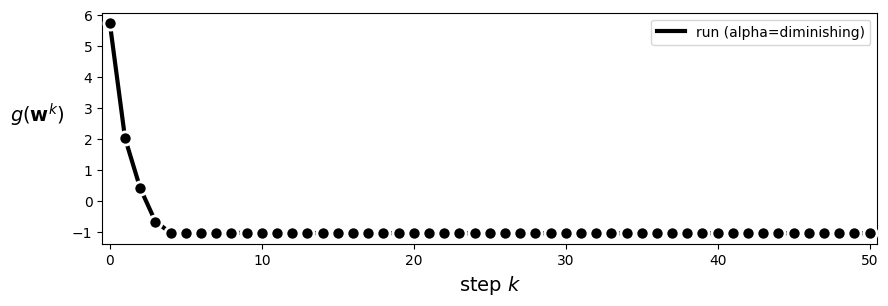

<function matplotlib.pyplot.show(close=None, block=None)>

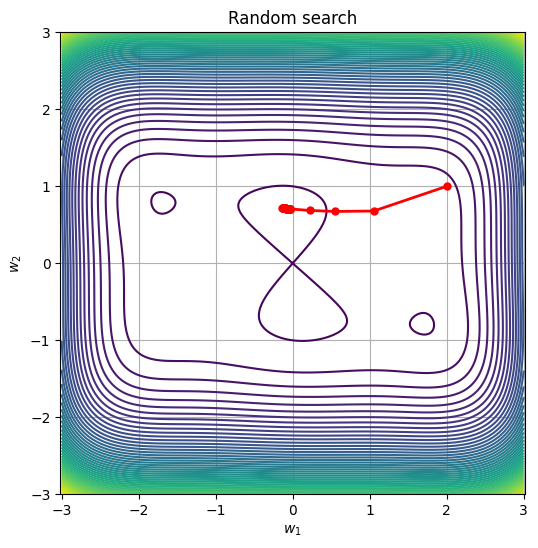

In [70]:
weight_history,cost_history = random_search(g,alpha_choice,max_its,w,num_samples)
#print("Weight history:\n", weight_history)
#print("Cost history:\n", cost_history)

# grid version for plotting
def g_grid(w1, w2):
    return w1**2 + w2**2 + 2

def g2_grid(w1, w2):
    return 100*(w2 - w1**2)**2 + (w1-1)**2

def g3_grid(w1, w2):
    return (
        (4.0 - 2.1*w1**2 + (w1**4)/3.0)*w1**2
        + w1*w2
        + (-4.0 + 4.0*w2**2)*w2**2
    )

# -----------------------
# Plot 1: cost history (MLRPlotting)
viz = static_plotter.Visualizer()
viz.plot_cost_histories([cost_history], start=0, points=True, labels=[f'run (alpha={alpha_choice})'])

# -----------------------
# Plot 2: contour + w_history overlay (MLRPlotting)
# pick a window that contains start (3,4) and the trajectory toward (0,0)

# grid for contour plot
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
Z = g3_grid(X, Y)

local_minima = np.array([[-.0898,.7162], [.0898,-7162]])

# plot the local minimum points

weight_history = np.array(weight_history)

plt.figure(figsize=(6, 6))
plt.contour(X, Y, Z, levels=50)
plt.plot(weight_history[:,0], weight_history[:,1],
         'ro-', linewidth=2, markersize=5)

plt.xlabel(r"$w_1$")
plt.ylabel(r"$w_2$")
plt.title(r"Random search")
plt.axis('equal')
plt.grid(True)
plt.show

In [ ]:
g = lambda w: np.dot(w.T,w) + 2
alpha_choice = 1; w = np.array([3,4]); num_samples = 1000; max_its = 5;
weight_history,cost_history = random_search(g,alpha_choice,max_its,w,num_samples)

In [ ]:
np.random.randn

In [ ]:
numpy.random.permutation